In [1]:
from mylib.statistic_test import *
import networkx as nx
# 3d plot
from mpl_toolkits.mplot3d import Axes3D
from mylib.maze_graph import CP_DSPs
from mylib.calcium.dsp_ms import get_son_area

code_id = '0811 - Cross-route correlation'
loc = os.path.join(figpath, 'Dsp', code_id)
mkdir(loc)

d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


        D:\Data\FinalResults\Dsp\0811 - Cross-route correlation is already existed!


False

# Fig. 2b, 2c

Mouse 10212


  0%|          | 0/7 [00:00<?, ?it/s]d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: divide by zero encountered in divide
  c /= stddev[:, None]
d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: divide by zero encountered in divide
  c /= stddev[None, :]
100%|██████████| 7/7 [00:15<00:00,  2.26s/it]


Mouse 10224


100%|██████████| 7/7 [00:24<00:00,  3.45s/it]


Mouse 10227


...

Mouse 10275


100%|██████████| 7/7 [00:25<00:00,  3.60s/it]


Mouse 10276


100%|██████████| 7/7 [00:24<00:00,  3.56s/it]


(756,)
[1 2 3 4 5 6]


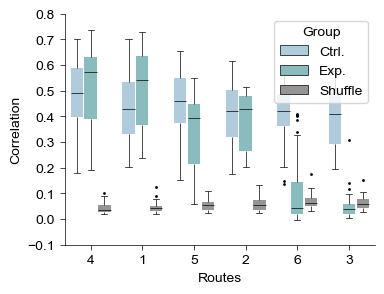

Route 5:
    Exp. vs. Control TtestResult(statistic=np.float64(3.910402807994072), pvalue=np.float64(0.9998305666503225), df=np.int64(41))
    Exp. vs. Shuffle TtestResult(statistic=np.float64(19.64157407582352), pvalue=np.float64(9.023645682886657e-23), df=np.int64(41))

Route 2:
    Exp. vs. Control TtestResult(statistic=np.float64(4.496129000859831), pvalue=np.float64(0.9999721167313746), df=np.int64(41))
    Exp. vs. Shuffle TtestResult(statistic=np.float64(18.925920649563736), pvalue=np.float64(3.5655792006961678e-22), df=np.int64(41))

Route 6:
    Exp. vs. Control TtestResult(statistic=np.float64(-6.535649393913015), pvalue=np.float64(3.744444713758748e-08), df=np.int64(41))
    Exp. vs. Shuffle TtestResult(statistic=np.float64(11.146687773016602), pvalue=np.float64(2.7590586358954274e-14), df=np.int64(41))

Route 3:
    Exp. vs. Control TtestResult(statistic=np.float64(-2.5237298925626663), pvalue=np.float64(0.007790601249907379), df=np.int64(41))
    Exp. vs. Shuffle TtestResu

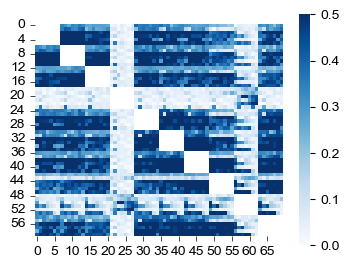

In [4]:
def RoutewiseCorrelation(trace: dict):
    maze_type = trace['maze_type']
    CPs = CP_DSPs[maze_type]
    if maze_type != 4:
        n_nodes = 10
    elif maze_type == 4:
        n_nodes = 11 if 'node 15' not in trace.keys() else 16
    corr_mat = np.ones((n_nodes, n_nodes), np.float64)
    
    for i in range(n_nodes - 1):
        for j in range(i+1, n_nodes):
            corr = []
            #idx = np.arange(trace['n_neuron'])
            idx = np.where(
                (trace[f'node {i}']['is_placecell'] == 1) |
                (trace[f'node {j}']['is_placecell'] == 1)
            )[0]
            bins = get_son_area(np.intersect1d(
                CPs[trace[f'node {i}']['Route']],
                CPs[trace[f'node {j}']['Route']],
            ))-1
            
            for k in idx:
                corr.append(np.corrcoef(
                    trace['node '+str(i)]['smooth_map_all'][k, bins], 
                    trace['node '+str(j)]['smooth_map_all'][k, bins]
                )[0,1])
            
            corr_mat[i, j] = corr_mat[j, i] = np.nanmean(np.asarray(corr))
    
    return corr_mat

if os.path.exists(os.path.join(figdata, f"{code_id}.pkl")) == False:
    mat = np.zeros((60, 70))
    for j, mice in enumerate([10212, 10224, 10227, 10232, 10275, 10276]):
        idx = np.where(f2['MiceID'] == mice)[0]
    
        print(f"Mouse {mice}")
        for d, i in tqdm(enumerate(idx)):
            try:
                with open(f2['Trace File'][i], 'rb') as handle:
                    trace = pickle.load(handle)
            except Exception as e:
                print(f"{f2['Trace File'][i]}: {e}")
                assert False
        
            idx = np.ix_(np.arange(10) + 10 * j, np.arange(10) + 10 * d)
            corr = trace['route_wise_corr']
            mat[idx] += corr
            mat[(np.arange(10) + 10 * j, np.arange(10) + 10 * d)] = np.nan
    
    with open(os.path.join(figdata, code_id+'.pkl'), 'wb') as handle:
        pickle.dump(mat, handle)
        
    # Save the matrix as an Excel sheet
    df = pd.DataFrame(mat)
    df.to_excel(os.path.join(figdata, code_id+'.xlsx'), index=False)
else:
    with open(os.path.join(figdata, code_id+'.pkl'), 'rb') as handle:
        mat = pickle.load(handle)
        
if os.path.exists(os.path.join(figdata, f" {code_id} [with length].pkl")) == False:

    Data = {
        "MiceID": [],
        "Routes": [],
        "Correlation": [],
        "Training Day": [],
        "Group": []
    }
    
    route_mat = np.zeros((10, 10))
    route_mat[:, np.array([0, 4, 5, 9])] = 1
    route_mat[:, 1] = 2
    route_mat[:, 2] = 3
    route_mat[:, 3] = 4
    route_mat[:, 6] = 5
    route_mat[:, 7] = 6
    route_mat[:, 8] = 7
    
    triu_idx = np.concatenate([
        np.arange(1, 10),
        np.arange(4, 10),
        np.arange(5, 10)
    ])
    I = np.intersect1d
            
    bins = [
        np.concatenate([Father2SonGraph[i] for i in CP_DSPs[1][j]])-1
        for j in [0, 1, 2, 3, 0, 0, 4, 5, 6, 0]
    ]    
    routes_stad = [0, 1, 2, 3, 0, 0, 4, 5, 6, 0]
    for mice in [10212, 10224, 10227, 10232, 10275, 10276]:
        idx = np.where(f2['MiceID'] == mice)[0]
    
        print(f"Mouse {mice}")
        for i in tqdm(idx):
            with open(f2['Trace File'][i], 'rb') as handle:
                trace = pickle.load(handle)
            
            for r in [1, 2, 3, 6, 7, 8]:
                if r in [1, 2, 3]:
                    ctrl0, ctrl1 = 0, 4
                else:
                    ctrl0, ctrl1 = 5, 9
                
                corr = np.zeros((trace['n_neuron'], 3), np.float64)
                
                for k in range(trace['n_neuron']):
                    corr[k, 0] = np.corrcoef(
                        trace[f'node {r}']['smooth_map_all'][k, bins[r]], 
                        trace[f'node {ctrl0}']['smooth_map_all'][k, bins[r]],
                    )[0, 1]
                    
                    corr[k, 1] = np.corrcoef(
                        trace[f'node {r}']['smooth_map_all'][k, bins[r]], 
                        trace[f'node {ctrl1}']['smooth_map_all'][k, bins[r]],
                    )[0, 1]
                
                    corr[k, 2] = np.corrcoef(
                        trace[f'node {ctrl0}']['smooth_map_all'][k, bins[r]], 
                        trace[f'node {ctrl1}']['smooth_map_all'][k, bins[r]],
                    )[0, 1]
                
                corr_value = np.nanmean(corr[:, 0])
                ctrl_value = np.nanmean(corr[:, 2])
                
                shuf_corr = np.zeros((trace['n_neuron'], 10), np.float64)
                cell_idx_perm = [
                    np.random.permutation(trace['n_neuron']) for i in range(10)
                ]
                for k in range(trace['n_neuron']):
                    for j in range(10):
                        shuf_corr[k, j] = np.corrcoef(
                            trace[f'node {r}']['smooth_map_all'][k, bins[r]], 
                            trace[f'node {r}']['smooth_map_all'][cell_idx_perm[j][k], bins[r]],
                        )[0, 1]
                
                shuf_value = np.nanmean(shuf_corr)
    
                Data['MiceID'].append(np.repeat(mice, 3))
                Data['Correlation'].append(np.array([corr_value, ctrl_value, shuf_value]))
                Data['Routes'].append(np.repeat(routes_stad[r], 3))
                Data['Training Day'].append(np.repeat(f2['training_day'][i], 3))
                Data['Group'].append(np.array(["Exp.", "Ctrl.", "Shuffle"]))
                
    for k in Data.keys():
        Data[k] = np.concatenate(Data[k])
        
    print(Data['Correlation'].shape)
    
    with open(os.path.join(figdata, code_id+' [with length].pkl'), 'wb') as handle:
        pickle.dump(Data, handle)
        
    D = pd.DataFrame(Data)
    D.to_excel(os.path.join(figdata, code_id+' [with length].xlsx'), index = False)
else:
    with open(os.path.join(figdata, code_id+' [with length].pkl'), 'rb') as handle:
        Data = pickle.load(handle)
        
print(np.unique(Data['Routes']))
SubData = Data
fig = plt.figure(figsize=(4,3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
box = sns.boxplot(
    x = 'Routes', 
    order=[4, 1, 5, 2, 6, 3],
    y = 'Correlation', 
    data = SubData, 
    hue_order=['Ctrl.', 'Exp.', 'Shuffle'],
    hue = 'Group',
    ax=ax,
    #err_style="bars",
    linewidth=0.5,
    width=0.8,
    linecolor='black',
    gap=0.1,
    fliersize=1,
    palette=[DSPPalette[0], DSPPalette[1], sns.color_palette("Grays", 3)[1]],
    #err_kws={'elinewidth': 0.5, 'capsize': 4, 'capthick': 0.5},
    #marker='o',
    #markersize=4,
    #markeredgewidth = 0,
    #palette=DSPPalette[:3]
)
for b in box.patches:
    b.set_linewidth(0)
    
ax.set_ylim(-0.1, 0.8)
ax.set_yticks(np.linspace(-0.1, 0.8, 10))
plt.savefig(os.path.join(loc, f'withlength.svg'), dpi=600)
plt.savefig(os.path.join(loc, f'withlength.png'), dpi=600)
plt.show()

for route in [4, 1, 5, 2, 6, 3]:
    idx_exp = np.where((Data['Routes'] == route) & (Data['Group'] == 'Exp.'))[0]
    idx_ctrl = np.where((Data['Routes'] == route) & (Data['Group'] == 'Ctrl.'))[0]
    idx_shuf = np.where((Data['Routes'] == route) & (Data['Group'] == 'Shuffle'))[0]
    print(f"Route {route+1}:")
    print(f"    Exp. vs. Control", ttest_rel(Data['Correlation'][idx_exp], Data['Correlation'][idx_ctrl], alternative='less'))
    print(f"    Exp. vs. Shuffle", ttest_rel(Data['Correlation'][idx_exp], Data['Correlation'][idx_shuf], alternative='greater'), end='\n\n')

# Sort Day
sort_day_idx = np.concatenate([np.arange(7)*10 + i for i in range(10)])
sort_mice_idx = np.concatenate([np.arange(5, -1, -1)*10 + i for i in range(10)])
sorted_mat = mat[sort_mice_idx, :][:, sort_day_idx]
fig = plt.figure(figsize=(4,3))
ax = Clear_Axes(plt.axes())
sns.heatmap(
    sorted_mat, vmin = 0, ax=ax, cmap='Blues', vmax=0.5
)
ax.set_aspect("equal")
plt.savefig(os.path.join(loc, f'allmice.svg'), dpi=600)
plt.savefig(os.path.join(loc, f'allmice.png'), dpi=600)
plt.show()



# Fig. 2i

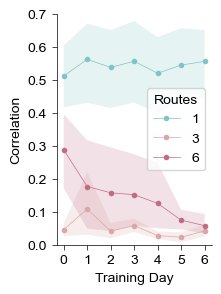

Route 2: 0.8025863860821636
Route 4: 0.11529072776436687
Route 7: 0.0032007194626628628


In [7]:
if os.path.exists(os.path.join(figdata, f"{code_id} [with length].pkl")):
    with open(os.path.join(figdata, f"{code_id} [with length].pkl"), 'rb') as handle:
        Data = pickle.load(handle)
else:
    raise FileNotFoundError(f"Please run Fig0811 - Cross-route Correlation.py to generate this file.")

if os.path.exists(os.path.join(figdata, f"{code_id} [Change over Time].pkl")) == False:
    SData = {
        "MiceID": [],
        "Routes": [],
        "Correlation": [],
        "Training Day": []
    }
    
    route_mat = np.zeros((10, 10))
    route_mat[:, np.array([0, 4, 5, 9])] = 1
    route_mat[:, 1] = 2
    route_mat[:, 2] = 3
    route_mat[:, 3] = 4
    route_mat[:, 6] = 5
    route_mat[:, 7] = 6
    route_mat[:, 8] = 7
    
    triu_idx = np.concatenate([
        np.arange(1, 10),
        np.arange(4, 10),
        np.arange(5, 10)
    ])
    I = np.intersect1d
    
    for mice in [10212, 10224, 10227, 10232, 10275, 10276]:
        idx = np.where(f2['MiceID'] == mice)[0]
    
        print(f"Mouse {mice}")
        for n, i in tqdm(enumerate(idx)):
            with open(f2['Trace File'][i], 'rb') as handle:
                trace = pickle.load(handle)
            
            corr_value = np.array([trace['route_wise_corr'][0, 1], trace['route_wise_corr'][0, 3], trace['route_wise_corr'][5, 8]])
            rts = np.array([1, 3, 6])
            
            SData['MiceID'].append(np.repeat(mice, rts.shape[0]))
            SData['Correlation'].append(corr_value)
            SData['Routes'].append(rts)
            SData['Training Day'].append(np.repeat(n, rts.shape[0]))

    for k in SData.keys():
        SData[k] = np.concatenate(SData[k])
    
    with open(os.path.join(figdata, f"{code_id} [Change over Time].pkl"), 'wb') as handle:
        pickle.dump(SData, handle)
        
    D = pd.DataFrame(SData)
    D.to_excel(os.path.join(figdata, f"{code_id} [Change over Time].xlsx"), index = False)
else:
    with open(os.path.join(figdata, f"{code_id} [Change over Time].pkl"), 'rb') as handle:
        SData = pickle.load(handle)


fig = plt.figure(figsize=(2, 3))
SubData = SData
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)


sns.lineplot(
    x = 'Training Day',
    y = 'Correlation',
    hue = 'Routes',
    hue_order=[1, 3, 6],
    data = SubData,
    palette=[DSPPalette[1], DSPPalette[3], DSPPalette[6]],
    linewidth=0.5,
    err_kws={'edgecolor':None},
    ax=ax,
    #err_style="bars",
    #err_kws={'elinewidth': 0.5, 'capsize': 3, 'capthick': 0.5},
    marker='o',
    markersize=4,
    markeredgewidth = 0,
)
ax.set_ylim([0, 0.7])
ax.set_yticks(np.linspace(0, 0.7, 8))
ax.set_xticks(np.linspace(0, 6, 7))
plt.savefig(join(loc, "Similarity with Route 1.png"), dpi = 600)
plt.savefig(join(loc, "Similarity with Route 1.svg"), dpi = 600)
plt.show()

for i in [1, 3, 6]:
    idx = np.where(SData['Routes'] == i)[0]
    x = SData['Training Day'][idx]
    y = SData['Correlation'][idx]
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    print(f"Route {i+1}: {p_value}")